# Setup

In [1]:
import math
from copy import deepcopy

import torch
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Gaussian

In [2]:
torch.set_default_dtype(torch.float64)

class Gaussian(torch.nn.Module):
    def __init__(self):
        super().__init__()

    def get_mean_cov(self):
        mean = torch.as_tensor([0.0])
        cov = torch.eye(1)
        return (mean, cov)

    def get_log_density(self, inputs, var_indices = None):
        (mean, cov) = self.get_mean_cov()
        if var_indices is not None:
            var_indices = torch.as_tensor(var_indices)
            cov = cov[var_indices[:, None], var_indices[None]]
            mean = mean[var_indices]
        dim = cov.shape[0]
        (det_sign, det_mag) = torch.linalg.slogdet(2*math.pi*cov)
        exp = torch.einsum("...i,ij,...j", inputs - mean, torch.linalg.inv(cov), inputs - mean)
        log_density = -0.5*det_sign*det_mag - 0.5*exp
        return log_density

    def sample(self, num_samples):
        (mean, cov) = self.get_mean_cov()
        expanded_mean = mean[None].expand(num_samples, -1)
        noise = torch.randn_like(expanded_mean)
        samples = expanded_mean + noise @ torch.linalg.cholesky(cov).T
        return samples

class CondGaussian(Gaussian):
    def __init__(self, x_or_y, corr_ratio, data_cov, data_mean):
        super().__init__()
        self.var = torch.nn.Parameter(data_cov[0, 0]*abs(torch.randn([1])).double())
        self.corr = torch.nn.Parameter(torch.randn([1]).double())
        self.mean = torch.nn.Parameter(torch.randn([1]).double())
        self.corr_ratio = corr_ratio
        self.data_cov = data_cov
        self.data_mean = data_mean
        self.x_y = x_or_y

    def get_mean_cov(self):
        mean = torch.cat([self.mean, self.data_mean])
        cov = torch.zeros([3, 3]).double()
        var = torch.nn.functional.softplus(self.var) + 1e-4
        corr = var*torch.nn.functional.tanh(self.corr)/(1 + self.corr_ratio + 1e-4)
        cov[1:, 1:] = self.data_cov
        cov[0, 0] = var
        if self.x_y == "x":
            cov[0, 1] = corr
            cov[1, 0] = corr
            cov[0, 2] = corr*self.corr_ratio
            cov[2, 0] = corr*self.corr_ratio
        else:
            cov[0, 1] = corr*self.corr_ratio
            cov[1, 0] = corr*self.corr_ratio
            cov[0, 2] = corr
            cov[2, 0] = corr
        return (mean, cov)

class FullGaussian(Gaussian):
    def __init__(self):
        super().__init__()
        self.cov_params = torch.nn.Parameter(torch.randn([3, 3]).double())
        self.mean = torch.nn.Parameter(torch.randn([3]).double())

    def get_mean_cov(self):
        chol_diagonal = torch.nn.functional.softplus(torch.diagonal(self.cov_params, 0)) + 1e-4
        chol = torch.diag_embed(chol_diagonal) + torch.tril(self.cov_params, -1)
        cov = chol @ chol.T
        return (self.mean, cov)

class IndGaussian(Gaussian):
    def __init__(self):
        super().__init__()
        self.prec_params = torch.nn.Parameter(torch.randn([3, 3]).double())
        self.mean = torch.nn.Parameter(torch.randn([3]).double())

    def get_mean_cov(self):
        chol_diagonal = torch.nn.functional.softplus(torch.diagonal(self.prec_params, 0)) + 1e-4
        chol = torch.diag_embed(chol_diagonal) + torch.tril(self.prec_params, -1)
        prec = chol @ chol.T
        prec[1, 2] = 0
        prec[2, 1] = 0
        cov = torch.linalg.inv(prec)
        return (self.mean, cov) 

def get_entropy(cov, var_indices = None):
    if var_indices is not None:
        var_indices = torch.as_tensor(var_indices)
        cov = cov[var_indices[:, None], var_indices[None]]
    dim = cov.shape[0]
    (det_sign, det_mag) = torch.linalg.slogdet(cov)
    entropy = 0.5*dim*(1 + math.log(2*math.pi)) + 0.5*det_sign*det_mag
    return entropy

def get_cross_entropy(mean_1, mean_2, cov_1, cov_2, var_indices = None):
    if var_indices is not None:
        var_indices = torch.as_tensor(var_indices)
        (cov_1, cov_2) = (cov_1[var_indices[:, None], var_indices[None]], cov_2[var_indices[:, None], var_indices[None]])
        (mean_1, mean_2) = (mean_1[var_indices], mean_2[var_indices])
    inv_cov_2 = torch.linalg.inv(cov_2)
    trace_prod = torch.einsum("ij,ij->", inv_cov_2, cov_1)
    diff_prod = torch.einsum("i,ij,j->", mean_1 - mean_2, inv_cov_2, mean_1 - mean_2)
    entropy = get_entropy(cov_2)
    cross_entropy = entropy + 0.5*(diff_prod + trace_prod - cov_2.shape[0])
    return cross_entropy

def get_multimodal_elbo(decoder, encoders, weights):
    (dec_mean, dec_cov) = decoder.get_mean_cov()
    values = {}
    var_index = [1, 2]
    for (encoder, weight, index) in zip(encoders, weights, var_index):
        (enc_mean, enc_cov) = encoder.get_mean_cov()
        marginal_ent = get_entropy(enc_cov, [index])
        joint_ent = get_entropy(enc_cov, [0, index])
        marginal_cross_ent = get_cross_entropy(enc_mean, dec_mean, enc_cov, dec_cov, [0])
        joint_cross_ent = get_cross_entropy(enc_mean, dec_mean, enc_cov, dec_cov)
        values.setdefault("reconstruction", []).append(marginal_cross_ent - joint_cross_ent)
        values.setdefault("regularizer", []).append(marginal_cross_ent + marginal_ent - joint_ent)
        values["elbo"] = values.get("elbo", 0) + weight*(joint_ent - joint_cross_ent - marginal_ent)
    return values

def get_mixture_divergence(encoders, weights, num_samples):
    cuml = 0
    for (i, (encoder, weight)) in enumerate(zip(encoders, weights), 1):
        samples = encoder.sample(num_samples)
        self_joint_density = encoder.get_log_density(samples[:, [0, i]], [0, i])
        self_marg_density = encoder.get_log_density(samples[:, i:i+1], [i])
        comb_joint_density = torch.log(sum([w*torch.exp(enc.get_log_density(samples)) for (enc, w) in zip(encoders, weights)]))
        comb_marg_density = torch.log(sum([w*torch.exp(enc.get_log_density(samples[:, 1:], [1, 2])) 
                                           for (enc, w) in zip(encoders, weights)]))
        cuml = cuml + weight*(self_joint_density - self_marg_density - comb_joint_density + comb_marg_density).mean()
    return cuml

def get_total_divergence(decoder, encoders, weights, num_samples):
    cuml = 0
    for (i, (encoder, weight)) in enumerate(zip(encoders, weights), 1):
        samples = encoder.sample(num_samples)
        decoder_density = decoder.get_log_density(samples)
        comb_density = torch.log(sum([w*torch.exp(enc.get_log_density(samples)) for (enc, w) in zip(encoders, weights)]))
        cuml = cuml + weight*(comb_density - decoder_density).mean()
    return cuml

## Training

In [88]:
all_results = {}

In [89]:
# Data distribution
x_mean = 0.0
y_mean = 0.0
x_var = 10.0
y_var = 10.0

corrs = [0.4]

i = 0
while True:
    valid = True
    corr = corrs[i]
    cov = corr*(x_var*y_var)**0.5
    data_cov = torch.as_tensor([[x_var, cov], [cov, y_var]]).double()

    # Encoder distributions
    weights = [0.5, 0.5]
    encoders = [
        CondGaussian("x", cov/x_var, data_cov, torch.as_tensor([x_mean, y_mean])),
        CondGaussian("y", cov/y_var, data_cov, torch.as_tensor([x_mean, y_mean]))]
    discrepancy = get_entropy(data_cov) - sum([w*get_entropy(data_cov, [i]) for (i, w) in enumerate(weights)])
    entropy = get_entropy(data_cov)
    
    # Decoder distribution
    # decoder = FullGaussian()
    decoder = IndGaussian()

    model = torch.nn.ModuleList([*encoders, decoder])
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    
    print(f"Corr {corr} - Target: {-entropy:.20f}")
    steps = 1000000
    states = {}
    best = (-math.inf, 0, deepcopy(model.state_dict()))
    for step in range(steps):
        optimizer.zero_grad()
        elbo = get_multimodal_elbo(decoder, encoders, weights)
        target = elbo["elbo"] + get_mixture_divergence(encoders, weights, 10)
        # if target > -entropy + 1e-5:
        #     valid = False
        #     break
        (-target).backward()
        optimizer.step()
        print(f"{step + 1}/{steps}: {target:.20f}                  ", end = "\r")
        diff = target.item() - best[0]
        if diff > 0:
            curr_state = deepcopy(model.state_dict())
            if diff > 1e-10 and (not states or step - list(states)[-1] > 100):
                states[step] = curr_state
            best = (target.item(), step, curr_state)
        if step - best[1] > 10000:
            break
    if not valid:
        continue
    if best[2]:
        model.load_state_dict(best[2])
    all_results[corr] = {"Multimodal ELBO": get_multimodal_elbo(decoder, encoders, weights)["elbo"], 
                         "Discrepancy": discrepancy, "Entropy": get_entropy(data_cov),
                         "Mixture Divergence": get_mixture_divergence(encoders, weights, 100000),
                         "Total Divergence": get_total_divergence(decoder, encoders, weights, 100000),
                         "states": states}
    if i < len(corrs) - 1:
        i += 1
    else:
        break

Corr 0.4 - Target: -5.05328546583100202128


## Analysis

In [90]:
all_quantities = {}
for (corr, results) in all_results.items():
    quantities = {"Step": [], "Multimodal ELBO": [], "X Encoder Z-X Corr": [], "X Encoder Z-Y Corr": [],
                  "Y Encoder Z-X Corr": [], "Y Encoder Z-Y Corr": [], "Decoder Z-X Corr": [], "Decoder Z-Y Corr": [],
                  "Mixture Divergence": [], "Total Divergence": [], "ELBO": []}
    for (step, state_dict) in results["states"].items():
        print(f"Processing step {step}    ", end = "\r")
        quantities["Step"].append(step)
        model.load_state_dict(state_dict)
        with torch.no_grad():
            elbo_dict = get_multimodal_elbo(decoder, encoders, weights)
            (cov_1, cov_2, dec_cov) = (encoders[0].get_mean_cov()[1], encoders[1].get_mean_cov()[1], decoder.get_mean_cov()[1])
            quantities["Multimodal ELBO"].append(elbo_dict["elbo"].item())
            quantities["X Encoder Z-X Corr"].append(abs(cov_1[0, 1]/(cov_1[0, 0]*cov_1[1, 1])**0.5).item())
            quantities["X Encoder Z-Y Corr"].append(abs(cov_1[0, 2]/(cov_1[0, 0]*cov_1[2, 2])**0.5).item())
            quantities["Y Encoder Z-X Corr"].append(abs(cov_2[0, 1]/(cov_2[0, 0]*cov_2[1, 1])**0.5).item())
            quantities["Y Encoder Z-Y Corr"].append(abs(cov_2[0, 2]/(cov_2[0, 0]*cov_2[2, 2])**0.5).item())
            quantities["Decoder Z-X Corr"].append(abs(dec_cov[0, 1]/(dec_cov[0, 0]*dec_cov[1, 1])**0.5).item())
            quantities["Decoder Z-Y Corr"].append(abs(dec_cov[0, 2]/(dec_cov[0, 0]*dec_cov[2, 2])**0.5).item())
            quantities["Mixture Divergence"].append(get_mixture_divergence(encoders, weights, 100000).item())
            quantities["Total Divergence"].append(get_total_divergence(decoder, encoders, weights, 100000).item())
            quantities["ELBO"].append(quantities["Multimodal ELBO"][-1] + quantities["Mixture Divergence"][-1])
    all_quantities[corr] = quantities

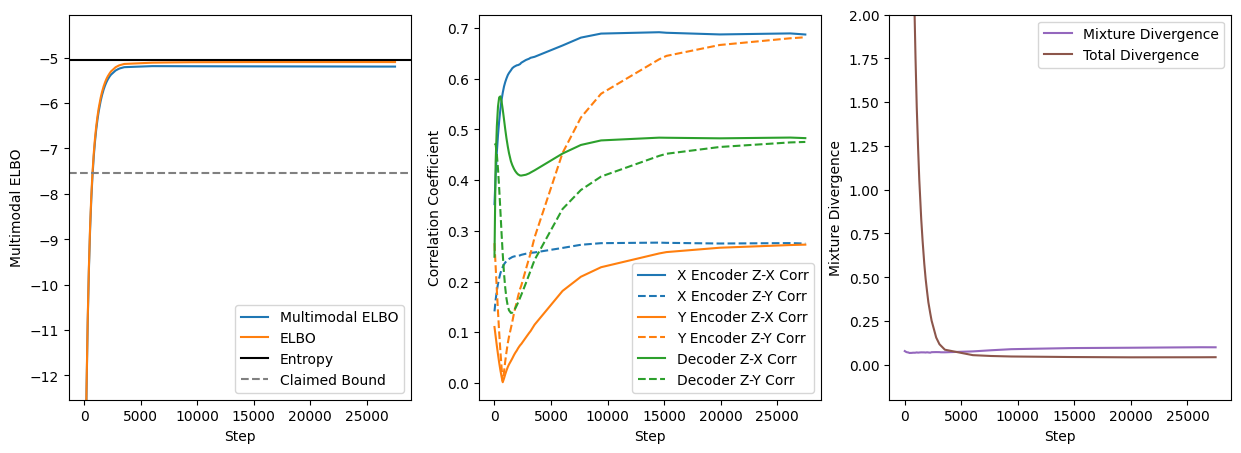

In [91]:
corr = 0.4

(fig, axes) = plt.subplots(1, 3, figsize = (15, 5))
sns.lineplot(all_quantities[corr], x = "Step", y = "Multimodal ELBO", ax = axes[0])
sns.lineplot(all_quantities[corr], x = "Step", y = "ELBO", ax = axes[0])
sns.lineplot(all_quantities[corr], x = "Step", y = "X Encoder Z-X Corr", ax = axes[1], c = "C0")
sns.lineplot(all_quantities[corr], x = "Step", y = "X Encoder Z-Y Corr", ax = axes[1], c = "C0", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Y Encoder Z-X Corr", ax = axes[1], c = "C1")
sns.lineplot(all_quantities[corr], x = "Step", y = "Y Encoder Z-Y Corr", ax = axes[1], c = "C1", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Decoder Z-X Corr", ax = axes[1], c = "C2")
sns.lineplot(all_quantities[corr], x = "Step", y = "Decoder Z-Y Corr", ax = axes[1], c = "C2", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Mixture Divergence", ax = axes[2], c = "C4")
sns.lineplot(all_quantities[corr], x = "Step", y = "Total Divergence", ax = axes[2], c = "C5")
(x_min, x_max) = axes[0].get_xlim()
axes[0].plot((x_min, x_max), [-entropy, -entropy], color = "black")
axes[0].plot((x_min, x_max), [-entropy - discrepancy, -entropy - discrepancy], color = "gray", linestyle = "dashed")
axes[0].set_ylim((-entropy - discrepancy - 5, -entropy + 1))
axes[0].set_xlim((x_min, x_max))
axes[2].set_ylim((-0.2, 2))
axes[0].legend(axes[0].lines, ["Multimodal ELBO", "ELBO", "Entropy", "Claimed Bound"])
axes[1].set_ylabel("Correlation Coefficient")
axes[1].legend(axes[1].lines, ["X Encoder Z-X Corr", "X Encoder Z-Y Corr", "Y Encoder Z-X Corr", "Y Encoder Z-Y Corr",
                               "Decoder Z-X Corr", "Decoder Z-Y Corr"])
axes[2].legend(axes[2].lines, ["Mixture Divergence", "Total Divergence"])
plt.show()

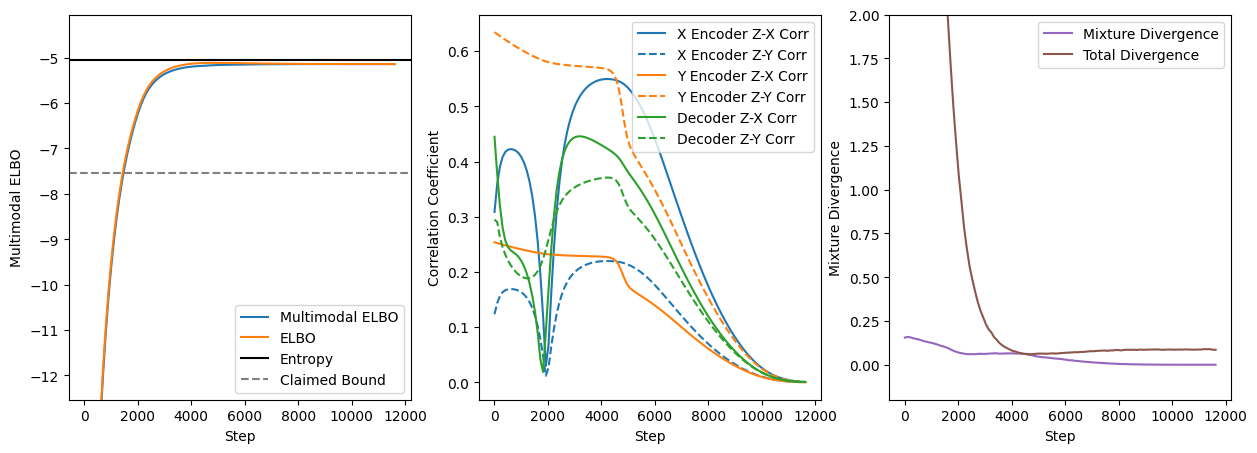

In [83]:
corr = 0.4

(fig, axes) = plt.subplots(1, 3, figsize = (15, 5))
sns.lineplot(all_quantities[corr], x = "Step", y = "Multimodal ELBO", ax = axes[0])
sns.lineplot(all_quantities[corr], x = "Step", y = "ELBO", ax = axes[0])
sns.lineplot(all_quantities[corr], x = "Step", y = "X Encoder Z-X Corr", ax = axes[1], c = "C0")
sns.lineplot(all_quantities[corr], x = "Step", y = "X Encoder Z-Y Corr", ax = axes[1], c = "C0", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Y Encoder Z-X Corr", ax = axes[1], c = "C1")
sns.lineplot(all_quantities[corr], x = "Step", y = "Y Encoder Z-Y Corr", ax = axes[1], c = "C1", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Decoder Z-X Corr", ax = axes[1], c = "C2")
sns.lineplot(all_quantities[corr], x = "Step", y = "Decoder Z-Y Corr", ax = axes[1], c = "C2", linestyle = "dashed")
sns.lineplot(all_quantities[corr], x = "Step", y = "Mixture Divergence", ax = axes[2], c = "C4")
sns.lineplot(all_quantities[corr], x = "Step", y = "Total Divergence", ax = axes[2], c = "C5")
(x_min, x_max) = axes[0].get_xlim()
axes[0].plot((x_min, x_max), [-entropy, -entropy], color = "black")
axes[0].plot((x_min, x_max), [-entropy - discrepancy, -entropy - discrepancy], color = "gray", linestyle = "dashed")
axes[0].set_ylim((-entropy - discrepancy - 5, -entropy + 1))
axes[0].set_xlim((x_min, x_max))
axes[2].set_ylim((-0.2, 2))
axes[0].legend(axes[0].lines, ["Multimodal ELBO", "ELBO", "Entropy", "Claimed Bound"])
axes[1].set_ylabel("Correlation Coefficient")
axes[1].legend(axes[1].lines, ["X Encoder Z-X Corr", "X Encoder Z-Y Corr", "Y Encoder Z-X Corr", "Y Encoder Z-Y Corr",
                               "Decoder Z-X Corr", "Decoder Z-Y Corr"])
axes[2].legend(axes[2].lines, ["Mixture Divergence", "Total Divergence"])
plt.show()

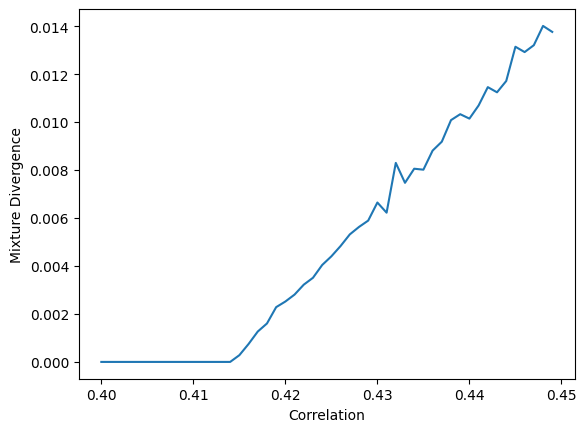

In [55]:
plot_data = {"Correlation": [], "Mixture Divergence": []}
for (corr, term_dict) in all_results.items():
    plot_data["Correlation"].append(corr)
    plot_data["Mixture Divergence"].append(abs(term_dict["Mixture Divergence"].item()))
sns.lineplot(plot_data, x = "Correlation", y = "Mixture Divergence")
plt.show()

# Categorical

In [92]:
import math
import random

torch.set_default_dtype(torch.float64)
class Probabilities():
    def __init__(self, prob_tensor, cond = []):
        self.probs = prob_tensor
        self.cond = set(cond)
        self.num_vars = self.probs.dim() - 1
        self.all_vars = list(range(self.num_vars + 1))
    
    def transform(self, out_vars, cond_vars = []):
        (out_vars, cond_vars) = (self.parse_vars(out_vars), self.parse_vars(cond_vars))
        cond_vars = self.cond.union(cond_vars)
        summed = [var for var in self.all_vars if var not in cond_vars]
        normalized = self.probs / self.probs.sum(summed, keepdim = True)
        marg_variables = [i for i in self.all_vars if i not in cond_vars.union(out_vars)]
        if marg_variables:
            probs = torch.sum(normalized, dim = tuple(marg_variables), keepdim = True)
        else:
            probs = normalized
        return Probabilities(probs, cond_vars)

    def add(self, prob_instances, weights, self_weight):
        new_probs = sum([w*inst.probs for (inst, w) in zip(prob_instances, weights)])
        new_probs = self_weight*self.probs + new_probs
        return Probabilities(new_probs, self.cond)

    def mul(self, prob_instances):
        new_cond = self.cond.intersection(*[inst.cond for inst in prob_instances])
        new_probs = math.prod([inst.probs for inst in prob_instances])
        return Probabilities(self.probs*new_probs, new_cond)

    def average(self, target):
        summed = [var for var in self.all_vars if var not in self.cond]
        average = (self.probs*target).sum(dim = summed, keepdim = True)
        return average
    
    def entropy(self, target = None):
        target_probs = self.probs if target is None else target.probs
        entropy = -self.average(torch.log2(target_probs))
        return entropy

    def divergence(self, target):
        divergence = self.entropy(target) - self.entropy()
        return divergence

    def parse_vars(self, var_arg):
        if var_arg == "z":
            var_list = [self.num_vars]
        elif var_arg == "data":
            var_list = list(range(self.num_vars))
        else:
            var_list = var_arg
        return var_list
        
class UnconstrainedProbs(torch.nn.Module):
    def __init__(self, num_vars, num_var_states, num_z_states):
        super().__init__()
        self.num_vars = num_vars
        self.params = torch.nn.Parameter(torch.randn([num_var_states]*num_vars + [num_z_states]).double())

    def forward(self):
        flat = torch.flatten(self.params)
        probs = torch.nn.functional.softmax(flat, 0).unflatten(0, self.params.shape)
        return Probabilities(probs)

class ComponentProbs(torch.nn.Module):
    def __init__(self, num_vars, num_var_states, num_z_states, dep_vars):
        super().__init__()
        self.dep_vars = dep_vars
        self.num_vars = num_vars
        non_z_init = torch.randn([num_var_states]*num_vars)
        z_init = torch.randn([num_var_states]*len(dep_vars) + [num_z_states])
        self.non_z_params = torch.nn.Parameter(non_z_init.double())
        self.z_params = torch.nn.Parameter(z_init.double())
        self.ein = [list(range(num_vars)), list(range(len(dep_vars))) + [num_vars], list(range(num_vars + 1))]
        self.permutation = torch.zeros([num_vars + 1]).long()
        self.permutation[dep_vars] = torch.arange(len(dep_vars))
        self.permutation[[i for i in range(num_vars + 1) if i not in dep_vars]] = torch.arange(len(dep_vars), num_vars + 1)

    def forward(self):
        non_z_probs = torch.nn.functional.softmax(self.non_z_params.flatten(), 0).unflatten(0, self.non_z_params.shape)
        z_probs = torch.nn.functional.softmax(self.z_params.flatten(end_dim = -2), 1).unflatten(0, self.z_params.shape[:-1])
        probs = torch.einsum(non_z_probs, self.ein[0], z_probs, self.ein[1], self.ein[2])
        probs = torch.permute(probs, tuple(self.permutation))
        return Probabilities(probs)

class CondProbs(torch.nn.Module):
    def __init__(self, num_vars, num_var_states, num_z_states):
        super().__init__()
        self.num_vars = num_vars
        z_params_init = torch.randn([1]*num_vars + [num_z_states])
        params_init = torch.randn([num_vars, num_z_states, num_var_states])
        self.z_params = torch.nn.Parameter(z_params_init.double())
        self.params = torch.nn.Parameter(params_init.double())
        self.indices = [[0, i] for i in range(1, num_vars + 1)]
        self.all_indices = list(range(num_vars + 1))

    def forward(self):
        factors = torch.unbind(self.params, 0)
        factor_probs = [torch.nn.functional.softmax(factor, -1) for factor in factors]
        einsum_args = [None]*(len(factor_probs) + len(self.indices))
        einsum_args[::2] = factor_probs
        einsum_args[1::2] = self.indices
        einsum_args.append(self.all_indices)
        probs = torch.einsum(*einsum_args)
        probs = torch.transpose(probs, 0, -1)
        probs = probs*torch.nn.functional.softmax(self.z_params, -1)
        return Probabilities(probs)

class PartitionedDecoder(torch.nn.Module):
    def __init__(self, num_vars, num_var_states, z_per_var):
        super().__init__()
        self.num_vars = num_vars
        num_z_states = num_vars*z_per_var
        z_params_init = torch.randn([1]*num_vars + [num_z_states])
        params_init = torch.randn([num_vars, num_z_states, num_var_states])
        self.z_params = torch.nn.Parameter(z_params_init.double())
        self.params = torch.nn.Parameter(params_init.double())
        self.indices = [[0, i] for i in range(1, num_vars + 1)]
        self.all_indices = list(range(num_vars + 1))

    def forward(self):
        factors = torch.unbind(self.params, 0)
        factor_probs = [torch.nn.functional.softmax(factor, -1) for factor in factors]
        einsum_args = [None]*(len(factor_probs) + len(self.indices))
        einsum_args[::2] = factor_probs
        einsum_args[1::2] = self.indices
        einsum_args.append(self.all_indices)
        probs = torch.einsum(*einsum_args)
        probs = torch.transpose(probs, 0, -1)
        probs = probs*torch.nn.functional.softmax(self.z_params, -1)
        return Probabilities(probs)

class DegenerateProbs(torch.nn.Module):
    def __init__(self, num_vars, num_var_states, num_z_states):
        super().__init__()
        self.num_vars = num_vars
        z_params_init = torch.randn([1]*num_vars + [num_z_states])
        xz_params_init = torch.randn([num_var_states] + [1]*(num_vars - 1) + [num_z_states])
        deg_probs = torch.zeros([num_var_states]*num_vars + [1])
        for i in range(num_var_states):
            deg_probs.__setitem__(tuple([i] + [i]*(num_vars - 1) + [0]), 1.0)
        self.z_params = torch.nn.Parameter(z_params_init.double())
        self.xz_params = torch.nn.Parameter(xz_params_init.double())
        self.deg_probs = deg_probs

    def forward(self):
        z_probs = torch.nn.functional.softmax(self.z_params, -1)
        xz_probs = torch.nn.functional.softmax(self.xz_params, 0)
        probs = z_probs*xz_probs*self.deg_probs
        return Probabilities(probs)

def compute_quantities(data_probs, decoder_probs, enc_prob_list, weights):
    comp_quantities = {}
    mix_probs = enc_prob_list[0].add(enc_prob_list[1:], weights[1:], weights[0])
    for encoder_probs in enc_prob_list:
        recon = -data_probs.mul([encoder_probs]).entropy(decoder_probs.transform("data", "z"))
        reg = data_probs.average(encoder_probs.divergence(decoder_probs.transform("z")))
        mix_div = data_probs.average(encoder_probs.divergence(mix_probs))
        comp_quantities.setdefault("reconstruction", []).append(recon)
        comp_quantities.setdefault("regularizer", []).append(reg)
        comp_quantities.setdefault("multimodal_elbo", []).append(recon - reg)
        comp_quantities.setdefault("mix_divergence", []).append(mix_div)
    quantities = {key: weighted_sum(values, weights) for (key, values) in comp_quantities.items()}
    quantities["cond_distance"] = data_probs.average(mix_probs.divergence(decoder_probs.transform("z", "data")))
    quantities["data_distance"] = data_probs.divergence(decoder_probs.transform("data"))
    quantities = {key: value.squeeze() for (key, value) in quantities.items()}
    return (comp_quantities, quantities)

def compute_discrepancy(data_probs, weights, deps):
    cuml = 0
    for (dep, weight) in zip(deps, weights):
        marg_vars = [i for i in data_probs.all_vars if i not in dep]
        cond_probs = data_probs.transform(marg_vars, dep)
        cond_entropy = data_probs.entropy(cond_probs)
        cuml += weight*cond_entropy
    return cuml

def weighted_sum(values, weights):
    return sum([w*value for (value, w) in zip(values, weights)])

In [3]:
def get_data_probs(num_vars, num_var_states, num_z_states, corr):
    deg_probs = Probabilities(DegenerateProbs(num_vars, num_var_states, num_z_states)().probs.detach()).transform("data")
    random_probs = Probabilities(UnconstrainedProbs(num_vars, num_var_states, num_z_states)().probs.detach()).transform("data")
    data_probs = random_probs.add([deg_probs], [corr], 1 - corr)
    return data_probs

def get_encoder_models(num_vars, num_var_states, num_z_states, deps):
    models = [ComponentProbs(num_vars, num_var_states, num_z_states, dep) for dep in deps]
    module = torch.nn.ModuleList(models)
    return module

def get_decoder_model(num_vars, num_var_states, num_z_states, constrained = True):
    prob_class = CondProbs if constrained else UnconstrainedProbs
    model = prob_class(num_vars, num_var_states, num_z_states)
    return model

def get_loss(name):
    if name == "multi":
        def loss(terms):
            return -terms["multimodal_elbo"]
    elif name == "elbo":
        def loss(terms):
            return -terms["multimodal_elbo"] - terms["mix_divergence"]
    return loss

In [4]:
num_vars = 2
num_var_states = 10
num_z_states = 5

deg_probs = Probabilities(DegenerateProbs(num_vars, num_var_states, num_z_states)().probs.detach()).transform("data")
random_probs = Probabilities(UnconstrainedProbs(num_vars, num_var_states, num_z_states)().probs.detach()).transform("data")

weights = [0.5, 0.5]
deps = [[0], [1]]

In [5]:
results = {}

In [9]:
exps = [("multi", corr) for corr in np.arange(0.10, 0.15, 0.001)]

for (loss_name, corr) in exps:
    data_probs = random_probs.add([deg_probs], [corr], 1 - corr)
    data_entropy = data_probs.entropy().squeeze()
    model = torch.nn.ModuleDict({
        "decoder": get_decoder_model(num_vars, num_var_states, num_z_states),
        "encoders": get_encoder_models(num_vars, num_var_states, num_z_states, deps)})
    discrepancy = compute_discrepancy(data_probs, weights, deps).squeeze()
    
    optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)
    loss_func = get_loss(loss_name)
    
    print(f"Corr {corr} - Target: {data_entropy:.20f}")
    steps = 20000
    states = {}
    best = (math.inf, 0, deepcopy(model.state_dict()))
    try:
        for step in range(steps):
            optimizer.zero_grad()
            decoder_probs = model["decoder"]()
            enc_prob_list = [encoder().transform("z", "data") for encoder in model["encoders"]]
            terms = compute_quantities(data_probs, decoder_probs, enc_prob_list, weights)[-1]
            target = loss_func(terms)
            target.backward()
            optimizer.step()
            print(f"{step + 1}/{steps}: {target:.20f}                  ", end = "\r")
            diff = target - best[0]
            if diff < 0:
                curr_state = deepcopy(model.state_dict())
                if abs(diff) > 1e-10 and (not states or step - list(states)[-1] > 100):
                    states[step] = curr_state
                best = (target, step, curr_state)
            if step - best[1] > 10000:
                break
    except KeyError:
        pass
    if best[2]:
        model.load_state_dict(best[2])
    (comp_terms, terms) = compute_quantities(data_probs, decoder_probs, enc_prob_list, weights)
    print(f"\n\nMultimodal ELBO: {terms['multimodal_elbo'].squeeze():.20f}")
    print(f"Discrepency: {discrepancy:.4g}")
    print(f"Gap: {-data_entropy - terms['multimodal_elbo']:.4g}")
    print(f"Mixture Divergence: {terms['mix_divergence']:.4g}")
    print(f"Conditional Divergence: {terms['cond_distance']:.4g}")
    print(f"Data Divergence: {terms['data_distance']:.4g}\n")
    results[(loss_name, corr)] = states

Corr 0.1 - Target: 6.40233216502507129775
20000/20000: 6.60726576300317347545                  

Multimodal ELBO: -6.60726576300317347545
Discrepency: 3.099
Gap: 0.2049
Mixture Divergence: 1.023e-10
Conditional Divergence: 7.008e-09
Data Divergence: 0.2049

Corr 0.101 - Target: 6.40144133365980749772
20000/20000: 6.60731051320865603316                  

Multimodal ELBO: -6.60731051320865603316
Discrepency: 3.098
Gap: 0.2059
Mixture Divergence: 8.652e-11
Conditional Divergence: 8.568e-09
Data Divergence: 0.2059

Corr 0.10200000000000001 - Target: 6.40054186808698766242
20000/20000: 6.60735390231975472375                  

Multimodal ELBO: -6.60735390231975472375
Discrepency: 3.097
Gap: 0.2068
Mixture Divergence: 5.172e-11
Conditional Divergence: 1.97e-09
Data Divergence: 0.2068

Corr 0.10300000000000001 - Target: 6.39963380773055057205
20000/20000: 6.60383405011872159918                  

Multimodal ELBO: -6.60383405011872159918
Discrepency: 3.096
Gap: 0.2042
Mixture Divergence: 0.02

KeyboardInterrupt: 

In [418]:
plot_data = {}
for (name, states) in results.items():
    quantities = {"Step": [], "Multimodal ELBO": [], "ELBO": [], "Encoder X-Z MI": [], "Decoder X-Z MI": [],
                 "Reconstruction": [], "Regularization": [], "Mixture Divergence": [], "Latent Divergence": [], "Data Divergence": []}
    for (step, state_dict) in states.items():
        print(f"Processing step {step}    ", end = "\r")
        quantities["Step"].append(step)
        model.load_state_dict(state_dict)
        decoder_probs = model["decoder"]()
        enc_prob_list = [encoder().transform("z", "data") for encoder in model["encoders"]]
        mix_joint = enc_prob_list[0].add(enc_prob_list[1:], weights[1:], weights[0]).mul([data_probs])
        with torch.no_grad():
            (comp_terms, terms) = compute_quantities(data_probs, decoder_probs, enc_prob_list, weights)
            enc_xz_mi = mix_joint.transform("z").entropy() - mix_joint.entropy(mix_joint.transform("z", "data"))
            dec_xz_mi = decoder_probs.transform("z").entropy() - decoder_probs.entropy(decoder_probs.transform("z", "data"))
            quantities["Multimodal ELBO"].append(terms["multimodal_elbo"].item())
            quantities["ELBO"].append(terms["multimodal_elbo"].item() + terms["mix_divergence"].item())
            quantities["Encoder X-Z MI"].append(enc_xz_mi.squeeze().item())
            quantities["Decoder X-Z MI"].append(dec_xz_mi.squeeze().item())
            quantities["Reconstruction"].append(terms["reconstruction"].item())
            quantities["Regularization"].append(terms["regularizer"].item())
            quantities["Mixture Divergence"].append(terms["mix_divergence"].item())
            quantities["Latent Divergence"].append(terms["cond_distance"].item())
            quantities["Data Divergence"].append(terms["data_distance"].item())
    plot_data[name] = quantities

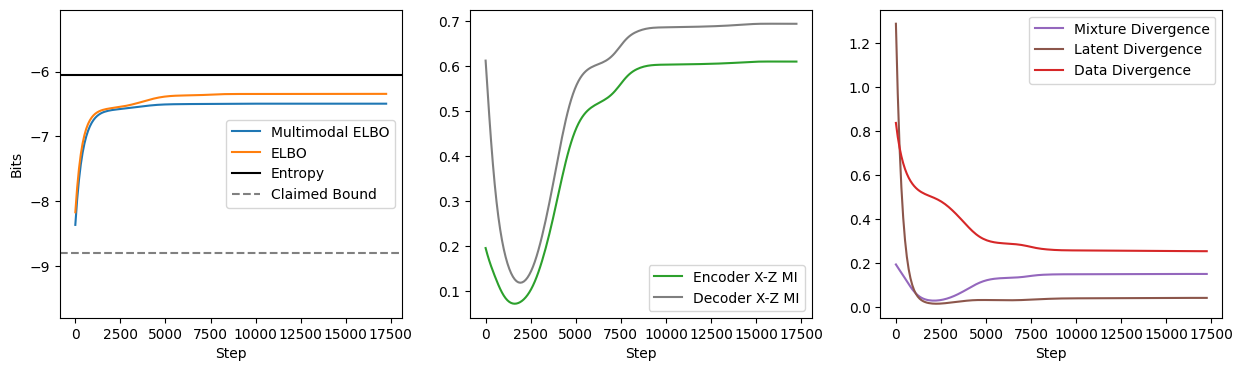

In [381]:
# Multimodal ELBO target, constrained decoder
quantities = plot_data["multi"]
(fig, axes) = plt.subplots(1, 3, figsize = (15, 4))
sns.lineplot(quantities, x = "Step", y = "Multimodal ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "Encoder X-Z MI", ax = axes[1], c = "C2")
sns.lineplot(quantities, x = "Step", y = "Decoder X-Z MI", ax = axes[1], c = "C7")
sns.lineplot(quantities, x = "Step", y = "Mixture Divergence", ax = axes[2], c = "C4")
sns.lineplot(quantities, x = "Step", y = "Latent Divergence", ax = axes[2], c = "C5")
sns.lineplot(quantities, x = "Step", y = "Data Divergence", ax = axes[2], c = "C3")
(x_min, x_max) = axes[0].get_xlim()
axes[0].plot((x_min, x_max), [-data_entropy, -data_entropy], color = "black")
axes[0].plot((x_min, x_max), [-data_entropy - discrepancy, -data_entropy - discrepancy], color = "gray", linestyle = "dashed")
axes[0].set_ylim((-data_entropy - discrepancy - 1, -data_entropy + 1))
axes[0].set_xlim((x_min, x_max))
# axes[1].set_ylim((-0.05, 0.85))
# axes[2].set_ylim((-0.05, 0.75))
axes[0].set_ylabel("Bits")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[0].legend(axes[0].lines, ["Multimodal ELBO", "ELBO", "Entropy", "Claimed Bound"])
axes[1].legend(axes[1].lines, ["Encoder X-Z MI", "Decoder X-Z MI"])
axes[2].legend(axes[2].lines, ["Mixture Divergence", "Latent Divergence", "Data Divergence"])
plt.show()

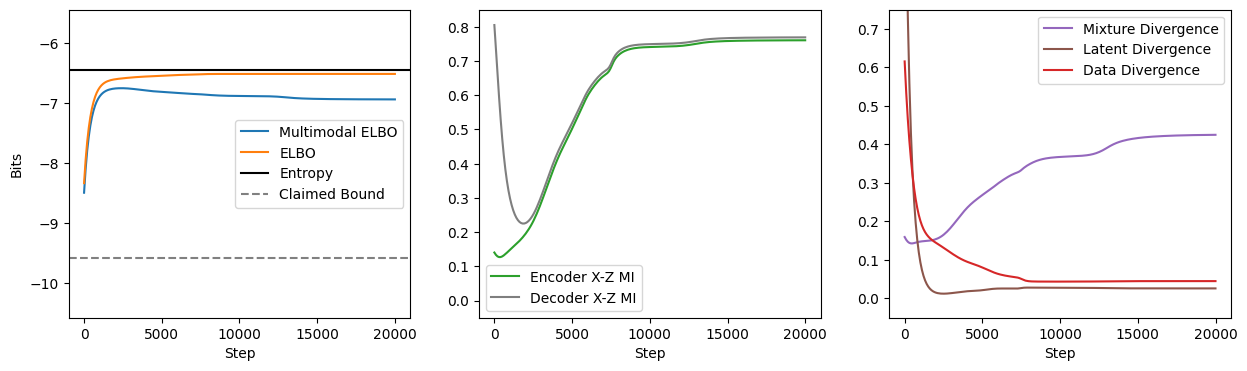

In [202]:
# ELBO target, constrained decoder
quantities = plot_data["elbo"]
(fig, axes) = plt.subplots(1, 3, figsize = (15, 4))
sns.lineplot(quantities, x = "Step", y = "Multimodal ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "Encoder X-Z MI", ax = axes[1], c = "C2")
sns.lineplot(quantities, x = "Step", y = "Decoder X-Z MI", ax = axes[1], c = "C7")
sns.lineplot(quantities, x = "Step", y = "Mixture Divergence", ax = axes[2], c = "C4")
sns.lineplot(quantities, x = "Step", y = "Latent Divergence", ax = axes[2], c = "C5")
sns.lineplot(quantities, x = "Step", y = "Data Divergence", ax = axes[2], c = "C3")
(x_min, x_max) = axes[0].get_xlim()
axes[0].plot((x_min, x_max), [-data_entropy, -data_entropy], color = "black")
axes[0].plot((x_min, x_max), [-data_entropy - discrepancy, -data_entropy - discrepancy], color = "gray", linestyle = "dashed")
axes[0].set_ylim((-data_entropy - discrepancy - 1, -data_entropy + 1))
axes[0].set_xlim((x_min, x_max))
axes[1].set_ylim((-0.05, 0.85))
axes[2].set_ylim((-0.05, 0.75))
axes[0].set_ylabel("Bits")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[0].legend(axes[0].lines, ["Multimodal ELBO", "ELBO", "Entropy", "Claimed Bound"])
axes[1].legend(axes[1].lines, ["Encoder X-Z MI", "Decoder X-Z MI"])
axes[2].legend(axes[2].lines, ["Mixture Divergence", "Latent Divergence", "Data Divergence"])
plt.show()

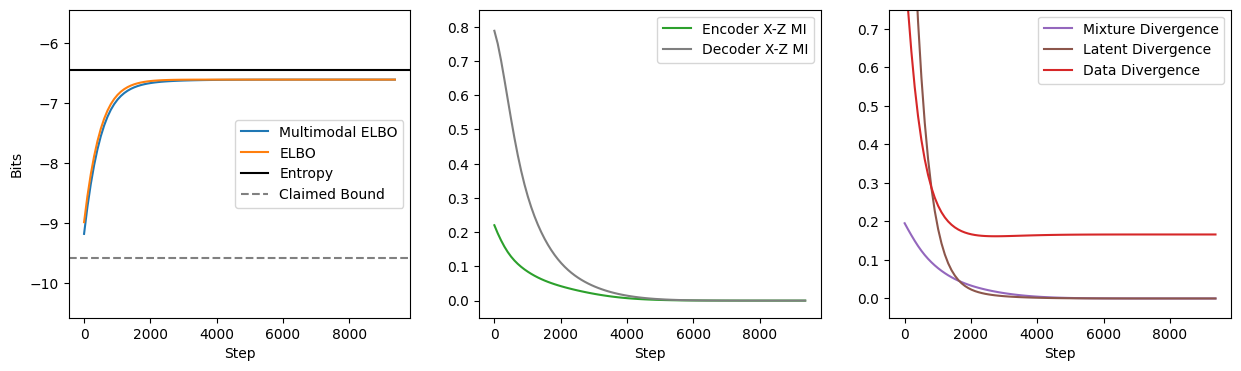

In [203]:
# Multimodal ELBO target, constrained decoder
quantities = plot_data["multi"]
(fig, axes) = plt.subplots(1, 3, figsize = (15, 4))
sns.lineplot(quantities, x = "Step", y = "Multimodal ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "ELBO", ax = axes[0])
sns.lineplot(quantities, x = "Step", y = "Encoder X-Z MI", ax = axes[1], c = "C2")
sns.lineplot(quantities, x = "Step", y = "Decoder X-Z MI", ax = axes[1], c = "C7")
sns.lineplot(quantities, x = "Step", y = "Mixture Divergence", ax = axes[2], c = "C4")
sns.lineplot(quantities, x = "Step", y = "Latent Divergence", ax = axes[2], c = "C5")
sns.lineplot(quantities, x = "Step", y = "Data Divergence", ax = axes[2], c = "C3")
(x_min, x_max) = axes[0].get_xlim()
axes[0].plot((x_min, x_max), [-data_entropy, -data_entropy], color = "black")
axes[0].plot((x_min, x_max), [-data_entropy - discrepancy, -data_entropy - discrepancy], color = "gray", linestyle = "dashed")
axes[0].set_ylim((-data_entropy - discrepancy - 1, -data_entropy + 1))
axes[0].set_xlim((x_min, x_max))
axes[1].set_ylim((-0.05, 0.85))
axes[2].set_ylim((-0.05, 0.75))
axes[0].set_ylabel("Bits")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[0].legend(axes[0].lines, ["Multimodal ELBO", "ELBO", "Entropy", "Claimed Bound"])
axes[1].legend(axes[1].lines, ["Encoder X-Z MI", "Decoder X-Z MI"])
axes[2].legend(axes[2].lines, ["Mixture Divergence", "Latent Divergence", "Data Divergence"])
plt.show()